# Business Case Study: Clustering in Learner Profiling

## Goal (Scaler’s perspective)
Cluster learners with similar professional profiles so Scaler can tailor course content, mentorship, and improve retention.

## Goal (How you’ll be evaluated)
This notebook performs:
- Exploratory Data Analysis (EDA)
- Preprocessing + feature engineering
- Clustering tendency (Hopkins statistic)
- K-means clustering (Elbow + silhouette, WCSS, coherence)
- Hierarchical clustering (dendrogram + interpretation)
- Cluster interpretation + actionable insights

> Note on confidentiality: the dataset uses anonymized identifiers. This notebook avoids revealing any real company names.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

# -----------------------------
# Load data
# -----------------------------
DATA_PATH = os.path.join('..', 'clustering', 'data', 'scaler_hashed_for_students.csv')
MAPPING_PATH = os.path.join('..', 'clustering', 'data', 'scaler_job_positions_mapping VX.csv')

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")
if not os.path.exists(MAPPING_PATH):
    raise FileNotFoundError(f"Mapping not found at: {MAPPING_PATH}")

df = pd.read_csv(DATA_PATH)

# Drop unnamed index column if present
if len(df.columns) > 0 and (str(df.columns[0]).lower().startswith('unnamed') or str(df.columns[0]).strip() == ''):
    df = df.drop(columns=[df.columns[0]])

# Standardize column names
expected_cols = {'company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position', 'ctc_updated_year'}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found columns: {list(df.columns)}")

# Coerce dtypes
for col in ['orgyear', 'ctc', 'ctc_updated_year']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean job_position
df['job_position'] = df['job_position'].astype(str).str.strip()

# Load job title mapping (messy -> standardized)
map_df = pd.read_csv(MAPPING_PATH)
map_df.columns = [c.strip() for c in map_df.columns]
if set(map_df.columns) != {'Original', 'New'}:
    raise ValueError(f"Unexpected mapping columns: {map_df.columns}")

mapping_dict = (
    map_df.assign(
        _orig=map_df['Original'].astype(str).str.strip().str.lower(),
        _new=map_df['New'].astype(str).str.strip(),
    )
    .set_index('_orig')['_new']
    .to_dict()
)

# Apply mapping (case-insensitive). Keep unknowns.
job_raw = df['job_position'].str.lower()
job_mapped = job_raw.map(mapping_dict)

# Normalize blanks/missing to 'Unknown'
is_blank = df['job_position'].isna() | (df['job_position'].str.strip() == '')

# Final cleaned title
# - if mapped exists, use mapped
# - else keep original (trimmed)
# - then normalize anything like 'others'/'other' to 'Other'
df['job_position_clean'] = job_mapped
fallback = df['job_position'].str.strip()
df['job_position_clean'] = df['job_position_clean'].fillna(fallback)
df.loc[is_blank, 'job_position_clean'] = 'Unknown'

df['job_position_clean'] = df['job_position_clean'].str.strip()
mask_other = df['job_position_clean'].str.lower().isin(['other', 'others'])
df.loc[mask_other, 'job_position_clean'] = 'Other'

print('Dataset shape:', df.shape)
print('\nMissing values (top):')
print(df.isna().sum().sort_values(ascending=False).head(15))

print('\nData types:')
print(df.dtypes)

display(df.head(3))

display(df['job_position_clean'].value_counts().head(10))


Dataset shape: (205843, 7)

Missing values (top):
job_position          52564
orgyear                  86
company_hash             44
email_hash                0
ctc                       0
ctc_updated_year          0
job_position_clean        0
dtype: int64

Data types:
company_hash              str
email_hash                str
orgyear               float64
ctc                     int64
job_position              str
ctc_updated_year      float64
job_position_clean        str
dtype: object


,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,job_position_clean
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0,Other
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0,fullstack devloper
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0,backend engineer


job_position_clean
Unknown                   52564
backend engineer          43555
fullstack devloper        25991
Other                     18723
frontend developer        10423
engineering leadership     6870
qa engineer                6587
data scientist             5370
android engineer           5357
software developer 1       4995
Name: count, dtype: int64

Duplicate rows: 34


,orgyear,ctc,ctc_updated_year
count,205757.000000,2.058430e+05,205843.000000
mean,2014.882750,2.271685e+06,2019.628231
std,63.571115,1.180091e+07,1.325104
min,0.000000,2.000000e+00,2015.000000
1%,2001.000000,3.700000e+04,2015.000000
5%,2007.000000,2.000000e+05,2017.000000
25%,2013.000000,5.300000e+05,2019.000000
50%,2016.000000,9.500000e+05,2020.000000
75%,2018.000000,1.700000e+06,2021.000000
95%,2020.000000,3.800000e+06,2021.000000


job_position    52564
orgyear            86
company_hash       44
dtype: int64

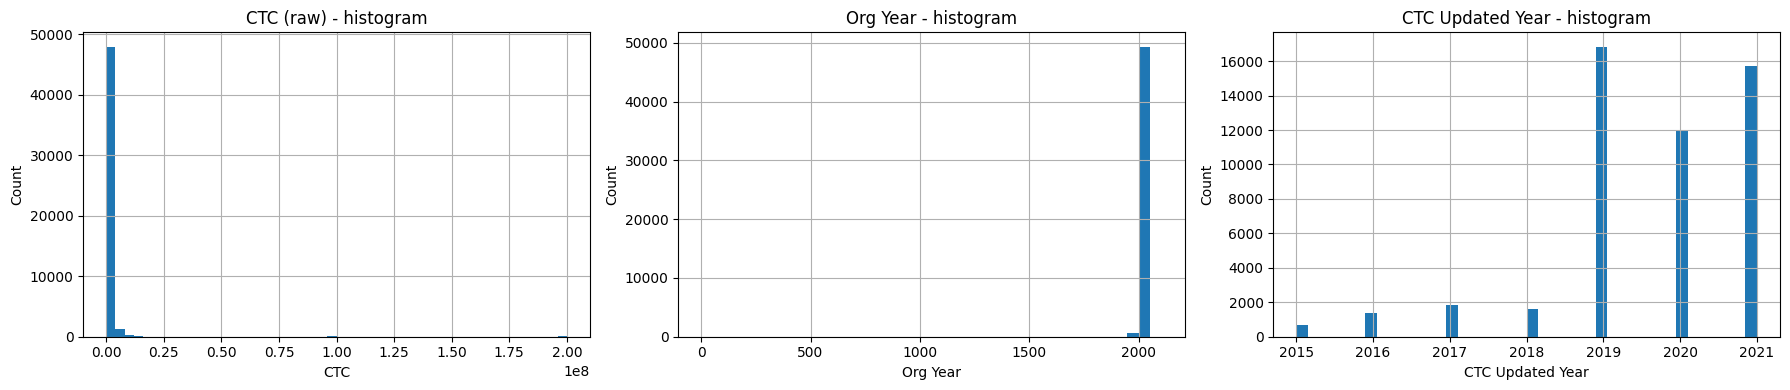

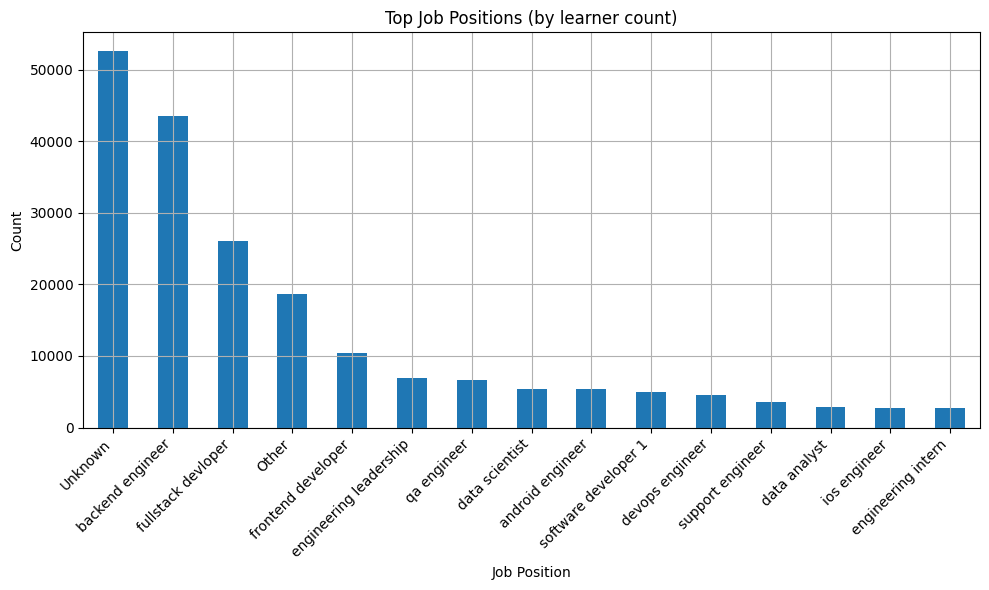

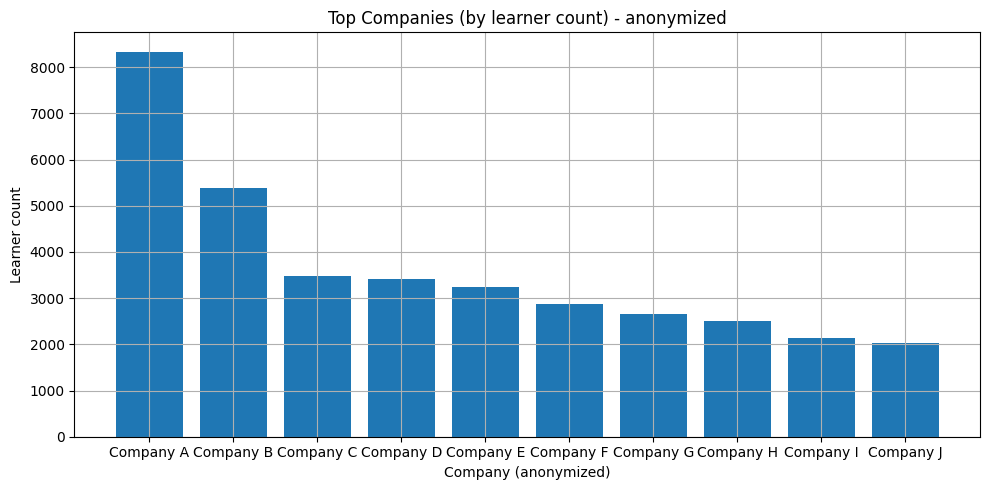

In [3]:
# -----------------------------
# EDA (baseline)
# -----------------------------
print('Duplicate rows:', df.duplicated().sum())

# Basic stats for numeric columns
numeric_cols = ['orgyear', 'ctc', 'ctc_updated_year']
desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
display(desc)

# Missingness overview
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

# Univariate: CTC distribution (sample for speed)
SAMPLE_N = 50000
sample = df[numeric_cols + ['job_position_clean', 'company_hash']].dropna().sample(
    n=min(SAMPLE_N, len(df)),
    random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(sample['ctc'], bins=50)
axes[0].set_title('CTC (raw) - histogram')
axes[0].set_xlabel('CTC')
axes[0].set_ylabel('Count')

axes[1].hist(sample['orgyear'], bins=40)
axes[1].set_title('Org Year - histogram')
axes[1].set_xlabel('Org Year')
axes[1].set_ylabel('Count')

axes[2].hist(sample['ctc_updated_year'], bins=40)
axes[2].set_title('CTC Updated Year - histogram')
axes[2].set_xlabel('CTC Updated Year')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Top job positions by frequency
job_counts = df['job_position_clean'].value_counts().head(15)
plt.figure(figsize=(10, 6))
job_counts.plot(kind='bar')
plt.title('Top Job Positions (by learner count)')
plt.xlabel('Job Position')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top companies by learner count (anonymized)
company_counts = df['company_hash'].value_counts().head(10)
company_labels = [f"Company {chr(ord('A') + i)}" for i in range(len(company_counts))]

plt.figure(figsize=(10, 5))
plt.bar(company_labels, company_counts.values)
plt.title('Top Companies (by learner count) - anonymized')
plt.xlabel('Company (anonymized)')
plt.ylabel('Learner count')
plt.tight_layout()
plt.show()


Cleaned dataset shape: (160229, 12)


,ctc,ctc_capped,years_experience,years_exp_capped,log_ctc
count,1.602290e+05,1.602290e+05,160229.000000,160229.000000,160229.000000
mean,2.475077e+06,1.531253e+06,5.142253,4.614633,13.757021
std,1.288074e+07,2.322009e+06,31.581787,3.991082,0.973665
min,2.000000e+00,3.600000e+04,0.000000,0.000000,10.491302
25%,5.500000e+05,5.500000e+05,2.000000,2.000000,13.217675
50%,9.700000e+05,9.700000e+05,4.000000,4.000000,13.785052
75%,1.700000e+06,1.700000e+06,6.000000,6.000000,14.346139
max,1.000150e+09,2.000000e+07,2021.000000,19.000000,16.811243


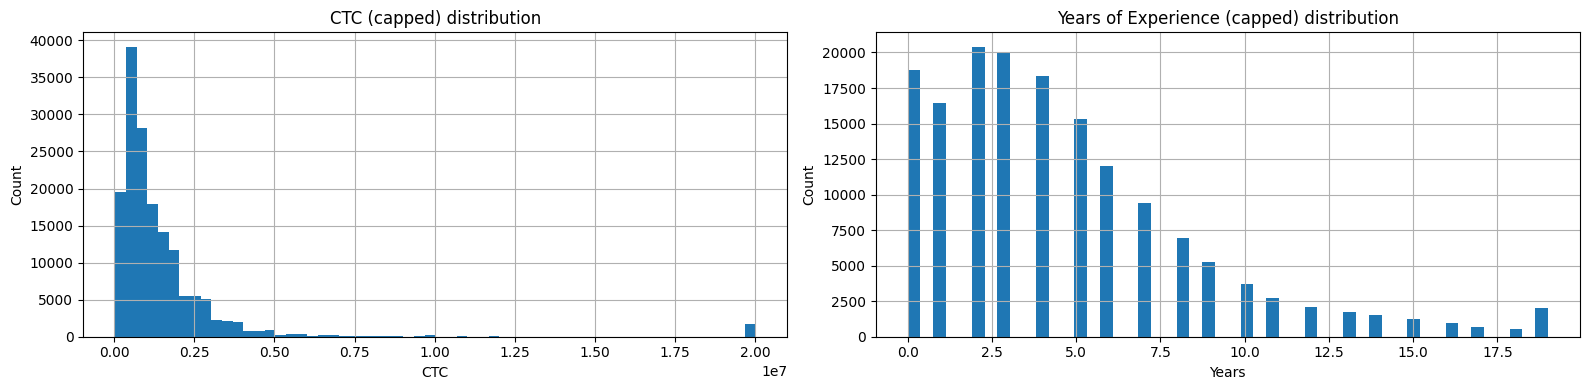

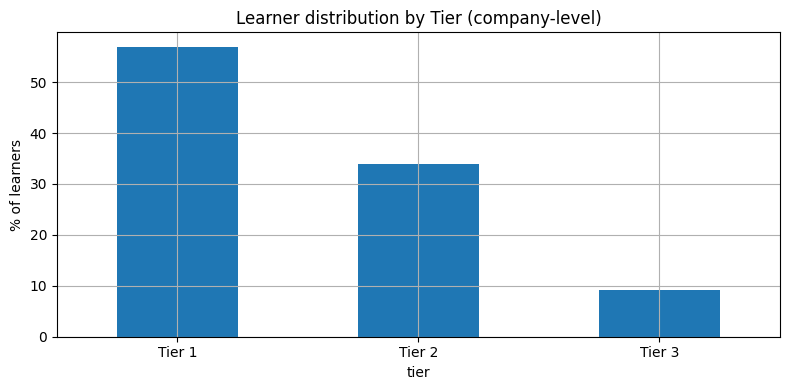

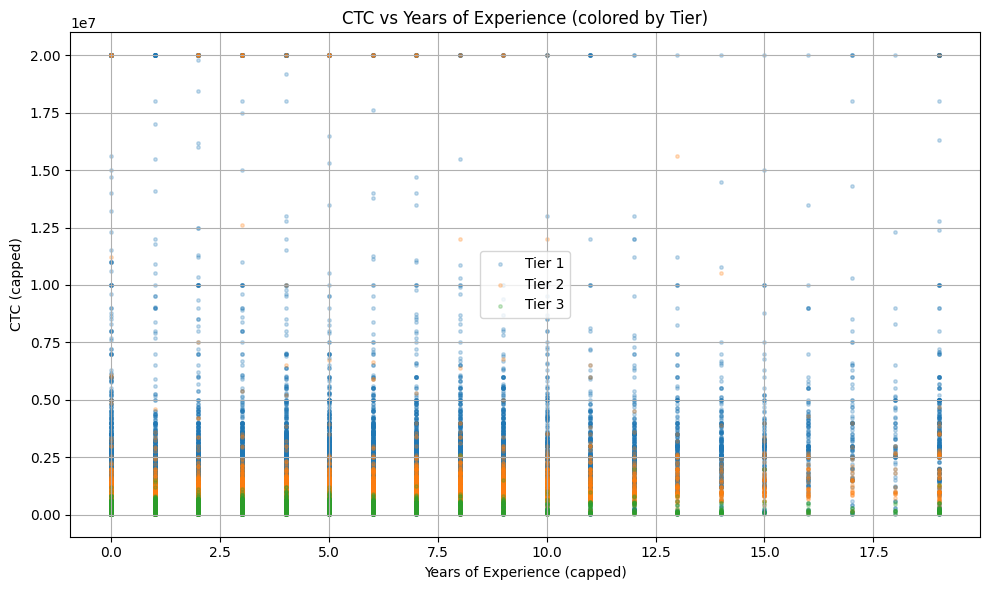

C:\Users\prath\AppData\Local\Temp\ipykernel_20464\3802837368.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ctc_by_tier, labels=['Tier 1', 'Tier 2', 'Tier 3'])


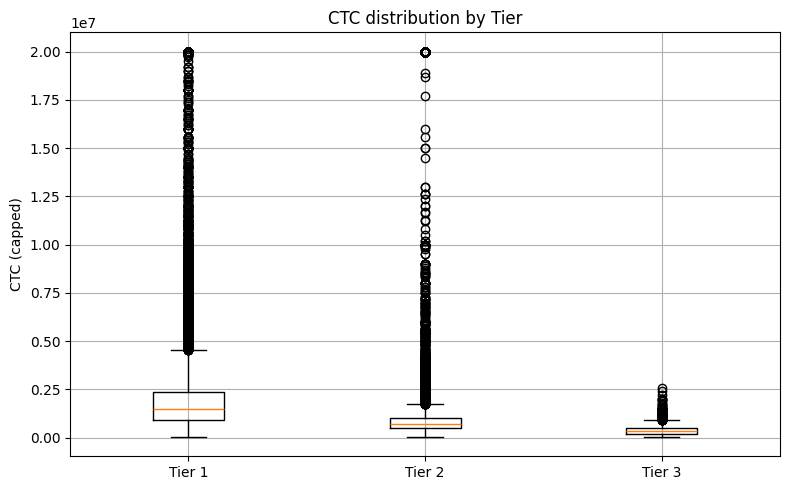

C:\Users\prath\AppData\Local\Temp\ipykernel_20464\3802837368.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ctc_groups, labels=plot_jobs, showfliers=False)


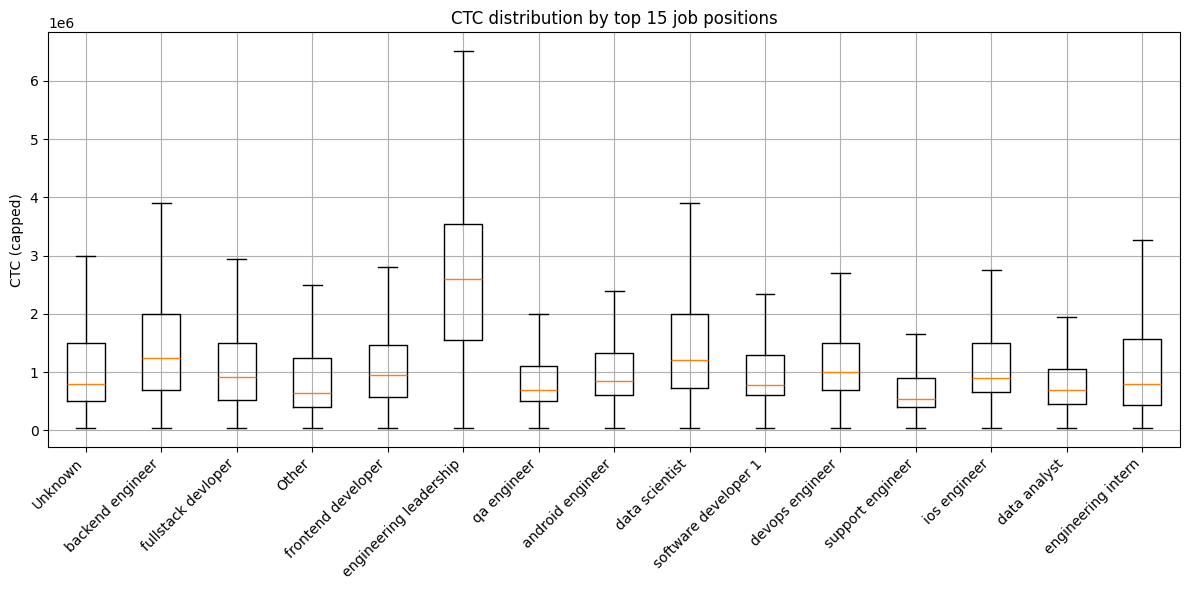

Example job_position_clean values: <StringArray>
[                 'Other',     'fullstack devloper',       'backend engineer',
                'Unknown',           'ios engineer',           'data analyst',
     'frontend developer',            'qa engineer', 'engineering leadership',
         'data scientist']
Length: 10, dtype: str


In [4]:
# -----------------------------
# Preprocessing + Feature Engineering
# -----------------------------

df2 = df.copy()

# Remove duplicates (same learner email within same company)
if 'email_hash' in df2.columns:
    df2 = df2.drop_duplicates(subset=['email_hash', 'company_hash'])
else:
    df2 = df2.drop_duplicates()

# Drop rows missing key numeric fields
key_cols = ['orgyear', 'ctc', 'ctc_updated_year']
df2 = df2.dropna(subset=key_cols)

# Feature: Years of Experience at the time of CTC update
# (Using ctc_updated_year - orgyear as a robust proxy)
df2['years_experience'] = (df2['ctc_updated_year'] - df2['orgyear']).clip(lower=0)

# Outlier treatment via capping (winsorization-like)
ctc_low, ctc_high = df2['ctc'].quantile([0.01, 0.99]).values
exp_low, exp_high = df2['years_experience'].quantile([0.01, 0.99]).values

df2['ctc_capped'] = df2['ctc'].clip(ctc_low, ctc_high)
df2['years_exp_capped'] = df2['years_experience'].clip(exp_low, exp_high)

df2['log_ctc'] = np.log1p(df2['ctc_capped'])

# Company Tier flag (create it as requested)
# Tier1 = companies with highest average CTC; Tier2 = middle; Tier3 = lowest.
company_mean_ctc = df2.groupby('company_hash')['ctc_capped'].mean()
q1, q2 = company_mean_ctc.quantile([1/3, 2/3]).values

def assign_tier(mean_ctc):
    if mean_ctc >= q2:
        return 'Tier 1'
    if mean_ctc >= q1:
        return 'Tier 2'
    return 'Tier 3'

tier_map = company_mean_ctc.apply(assign_tier).to_dict()
df2['tier'] = df2['company_hash'].map(tier_map)

print('Cleaned dataset shape:', df2.shape)
display(df2[['ctc', 'ctc_capped', 'years_experience', 'years_exp_capped', 'log_ctc', 'tier']].describe())

# -----------------------------
# Univariate quick checks
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(df2['ctc_capped'], bins=60)
axes[0].set_title('CTC (capped) distribution')
axes[0].set_xlabel('CTC')
axes[0].set_ylabel('Count')

axes[1].hist(df2['years_exp_capped'], bins=50)
axes[1].set_title('Years of Experience (capped) distribution')
axes[1].set_xlabel('Years')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
(df2['tier'].value_counts(normalize=True) * 100).plot(kind='bar')
plt.title('Learner distribution by Tier (company-level)')
plt.ylabel('% of learners')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# Bivariate EDA
# -----------------------------
# Scatter (sample for speed)
SCATTER_N = 30000
sc = df2[['years_exp_capped', 'ctc_capped', 'tier']].sample(n=min(SCATTER_N, len(df2)), random_state=42)

plt.figure(figsize=(10, 6))
for t, grp in sc.groupby('tier'):
    plt.scatter(grp['years_exp_capped'], grp['ctc_capped'], s=6, alpha=0.25, label=t)
plt.title('CTC vs Years of Experience (colored by Tier)')
plt.xlabel('Years of Experience (capped)')
plt.ylabel('CTC (capped)')
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot: CTC by Tier (matplotlib boxplot)
ctc_by_tier = [df2.loc[df2['tier'] == t, 'ctc_capped'].values for t in ['Tier 1', 'Tier 2', 'Tier 3']]
plt.figure(figsize=(8, 5))
plt.boxplot(ctc_by_tier, labels=['Tier 1', 'Tier 2', 'Tier 3'])
plt.title('CTC distribution by Tier')
plt.ylabel('CTC (capped)')
plt.tight_layout()
plt.show()

# Boxplot: CTC by top job positions
TOP_JOB = 15
job_top = df2['job_position_clean'].value_counts().head(TOP_JOB).index.tolist()
plot_jobs = job_top

ctc_groups = [df2.loc[df2['job_position_clean'] == j, 'ctc_capped'].sample(min(2000, (df2['job_position_clean'] == j).sum()), random_state=42).values
              for j in plot_jobs]

plt.figure(figsize=(12, 6))
plt.boxplot(ctc_groups, labels=plot_jobs, showfliers=False)
plt.title(f'CTC distribution by top {TOP_JOB} job positions')
plt.ylabel('CTC (capped)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Example job_position_clean values:', df2['job_position_clean'].unique()[:10])


Hopkins statistic (≈0.5 means weak/no clustering tendency): 0.9956374548901603
Elbow-selected k: 3
Silhouette-best k: 2


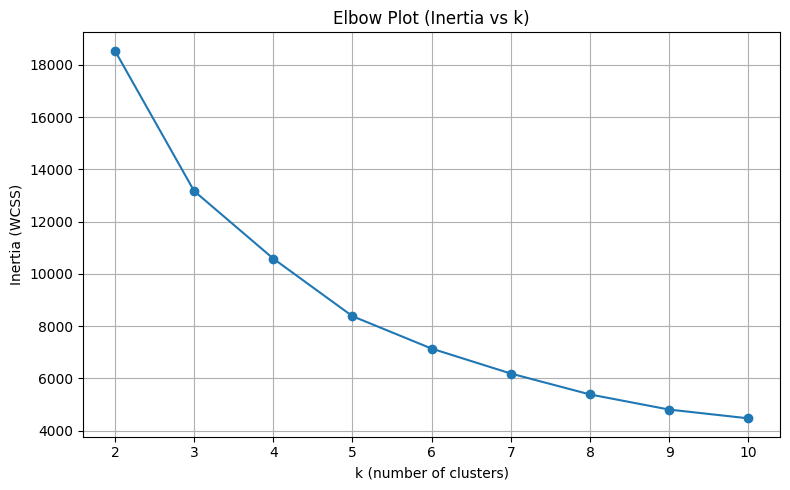

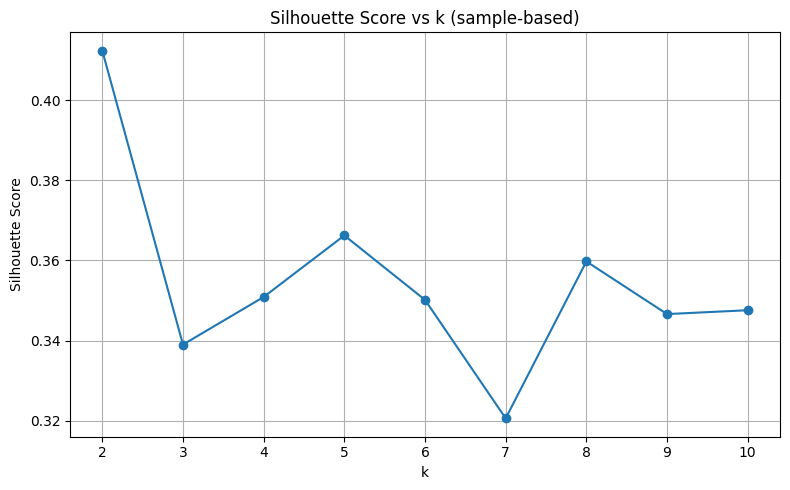

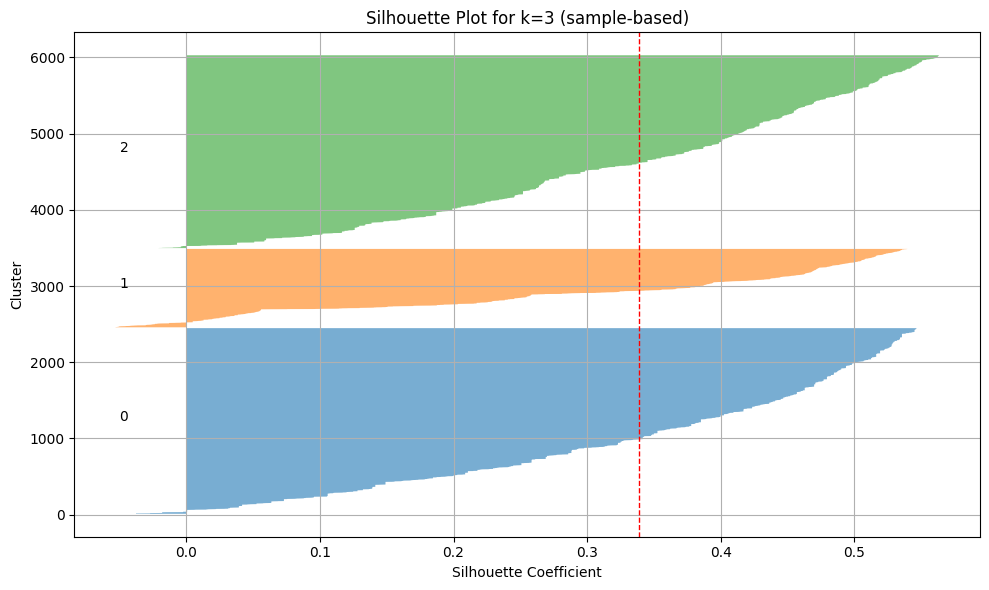

In [5]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_samples

# -----------------------------
# Clustering feature matrix
# -----------------------------
feature_cols = ['log_ctc', 'years_exp_capped']
X = df2[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Hopkins Statistic (clustering tendency)
# -----------------------------
def hopkins_statistic(X_arr, sample_size=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X_arr.shape
    m = min(sample_size, n // 2)

    # Sample points from dataset (w)
    idx = rng.choice(n, size=m, replace=False)
    X_sample = X_arr[idx]

    # Uniform random points in the bounding box (u)
    mins = X_arr.min(axis=0)
    maxs = X_arr.max(axis=0)
    U = rng.uniform(mins, maxs, size=(m, d))

    # Nearest neighbors on full dataset
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X_arr)

    # Distances for sample points: take 2nd neighbor (1st is itself)
    dists_sample, _ = nn.kneighbors(X_sample, return_distance=True)
    w_dist = dists_sample[:, 1]

    # Distances for random points
    u_dists, _ = nn.kneighbors(U, n_neighbors=1, return_distance=True)
    u_dist = u_dists[:, 0]

    # Hopkins statistic (higher => more tendency to cluster)
    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return float(H)

hopkins = hopkins_statistic(X_scaled, sample_size=2000, random_state=42)
print('Hopkins statistic (≈0.5 means weak/no clustering tendency):', hopkins)

# -----------------------------
# Elbow method (inertia) + silhouette (coherence)
# -----------------------------
ks = list(range(2, 11))

# Use a sample for speed
SAMPLE_FOR_ELBOW = min(15000, len(df2))
SAMPLE_FOR_SIL = min(6000, len(df2))

rng = np.random.default_rng(42)
idx_elbow = rng.choice(len(df2), size=SAMPLE_FOR_ELBOW, replace=False)
idx_sil = rng.choice(len(df2), size=SAMPLE_FOR_SIL, replace=False)

X_elbow = X_scaled[idx_elbow]
X_sil = X_scaled[idx_sil]

inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=300)
    km.fit(X_elbow)
    inertias.append(km.inertia_)

# Elbow selection using curvature (2nd derivative magnitude)
I = np.array(inertias)
# second derivative over ks internal points
if len(ks) >= 3:
    d1 = np.diff(I)
    d2 = np.diff(d1)
    curvature = np.abs(d2)
    best_elbow_idx = int(np.argmax(curvature))  # corresponds to ks[1:len(ks)-1]
    elbow_k = ks[1 + best_elbow_idx]
else:
    elbow_k = ks[0]

# Silhouette scores over ks (on sample)
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=300)
    labels = km.fit_predict(X_sil)
    sil = silhouette_score(X_sil, labels)
    sil_scores.append(sil)

best_sil_k = ks[int(np.argmax(sil_scores))]

print('Elbow-selected k:', elbow_k)
print('Silhouette-best k:', best_sil_k)

# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker='o')
plt.title('Elbow Plot (Inertia vs k)')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(ks)
plt.tight_layout()
plt.show()

# Plot silhouette score summary
plt.figure(figsize=(8, 5))
plt.plot(ks, sil_scores, marker='o')
plt.title('Silhouette Score vs k (sample-based)')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.xticks(ks)
plt.tight_layout()
plt.show()

# Silhouette plot for elbow_k
final_k = elbow_k
km_final = KMeans(n_clusters=final_k, random_state=42, n_init='auto', max_iter=300)
labels_final = km_final.fit_predict(X_sil)

sil_vals = silhouette_samples(X_sil, labels_final)

plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(final_k):
    ith_vals = sil_vals[labels_final == i]
    ith_vals.sort()
    size_i = len(ith_vals)
    y_upper = y_lower + size_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, alpha=0.6)
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sil_vals), color='red', linestyle='--', linewidth=1)
plt.title(f'Silhouette Plot for k={final_k} (sample-based)')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


Using final_k = 3
WCSS (inertia) for final_k: 138627.2885581939
Silhouette score (sample-based) for final_k: 0.3357449476775437


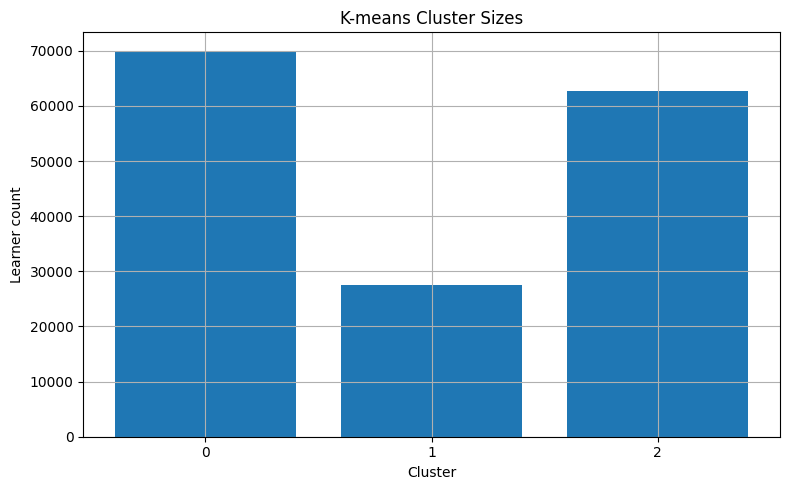

,learners,pct,mean_years,median_years,mean_ctc,median_ctc,job_top_1
kmeans_cluster,,,,,,,
0,69861,43.60,3.594566,4.0,2.101734e+06,1400000.0,backend engineer
2,62759,39.17,2.746028,2.0,4.663395e+05,480000.0,Unknown
1,27609,17.23,11.443370,10.0,2.508416e+06,1810000.0,backend engineer


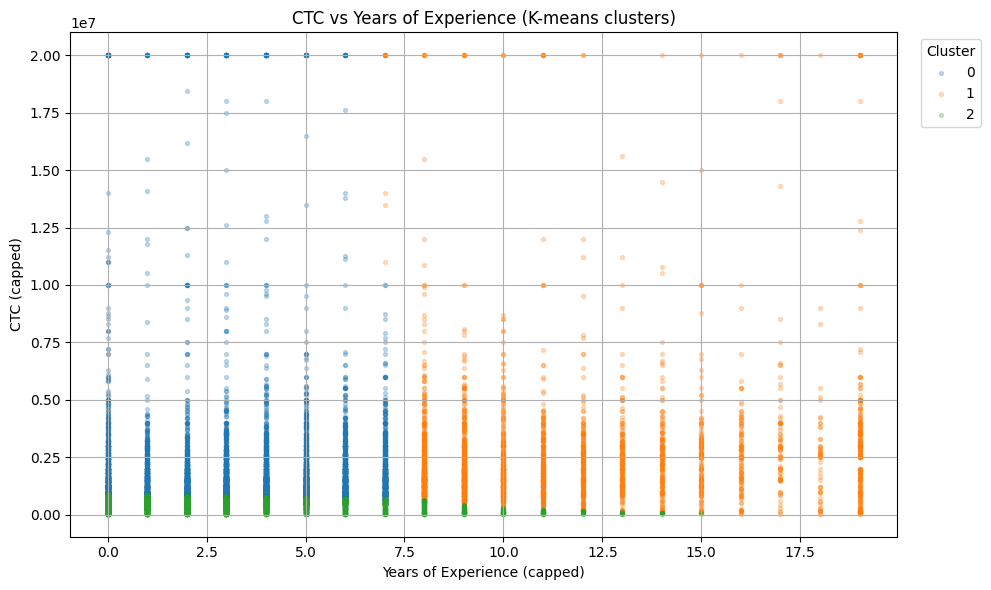

C:\Users\prath\AppData\Local\Temp\ipykernel_20464\1666871647.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ctc_box_data, labels=[str(c) for c in clusters_sorted], showfliers=False)


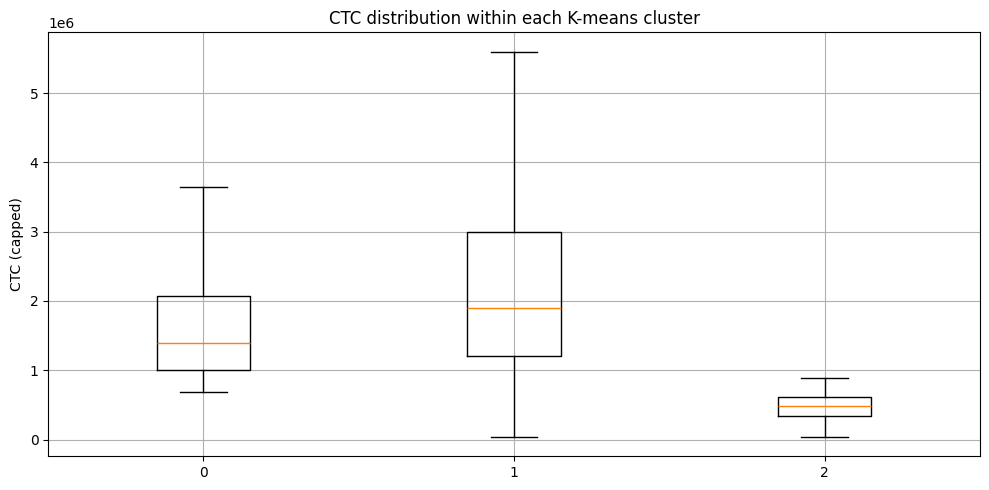

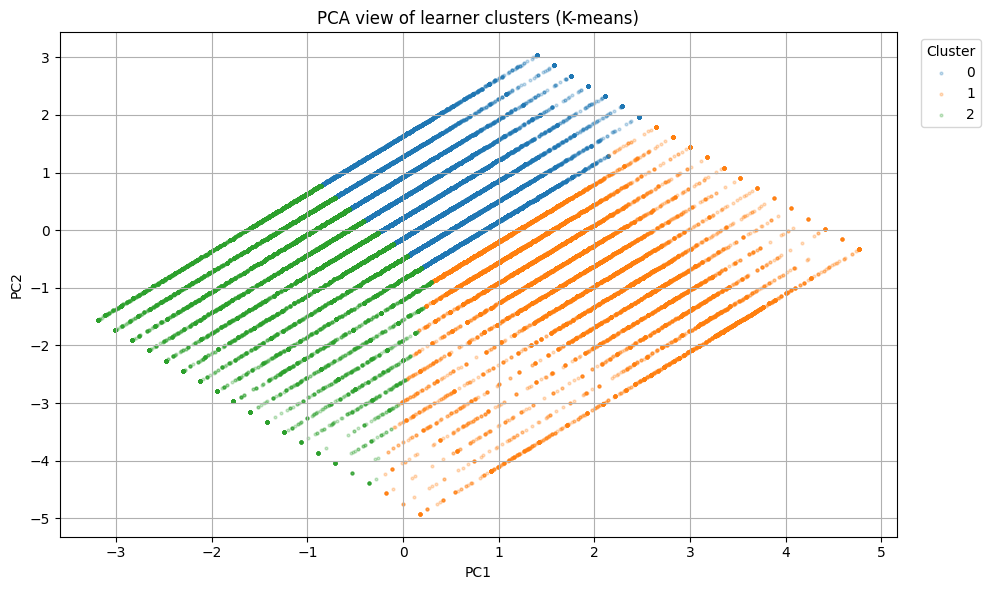


Dominant job positions per K-means cluster (top):
Cluster 0:
job_position_clean
backend engineer      19634
Unknown               15084
fullstack devloper     9201
Other                  4650
frontend developer     3838
data scientist         2604
Name: count, dtype: int64
Cluster 1:
job_position_clean
backend engineer          5091
Unknown                   4327
engineering leadership    4120
fullstack devloper        2272
Other                     1735
frontend developer        1656
Name: count, dtype: int64
Cluster 2:
job_position_clean
Unknown               16424
backend engineer      10295
Other                  8351
fullstack devloper     7938
frontend developer     3166
qa engineer            3153
Name: count, dtype: int64


In [6]:
# -----------------------------
# Final K-means clustering (learners profiling)
# -----------------------------

final_k = int(elbow_k)
print('Using final_k =', final_k)

# K-means: fit on a representative sample, then predict for all learners
TRAIN_SAMPLE_N = min(60000, len(df2))
idx_train = np.random.default_rng(42).choice(len(df2), size=TRAIN_SAMPLE_N, replace=False)
X_train = X_scaled[idx_train]

km_full = KMeans(n_clusters=final_k, random_state=42, n_init='auto', max_iter=500)
km_full.fit(X_train)

labels_full = km_full.predict(X_scaled)

# Attach cluster labels
df2['kmeans_cluster'] = labels_full

# Coherence: approximate WCSS on the full dataset using learned centers
# (distance to closest center squared, summed over all points)
dists = km_full.transform(X_scaled)  # Euclidean distances
sq_dists = (dists ** 2)
wcss = float(np.min(sq_dists, axis=1).sum())
print('WCSS (inertia) for final_k:', wcss)

# Silhouette on a sample for speed
SIL_SAMPLE_N = min(10000, len(df2))
idx_sil_full = np.random.default_rng(42).choice(len(df2), size=SIL_SAMPLE_N, replace=False)
X_sil_full = X_scaled[idx_sil_full]
labels_sil_full = df2['kmeans_cluster'].values[idx_sil_full]

sil_full = silhouette_score(X_sil_full, labels_sil_full)
print('Silhouette score (sample-based) for final_k:', sil_full)

# Cluster size distribution
cluster_sizes = df2['kmeans_cluster'].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(df2) * 100).round(2)

plt.figure(figsize=(8, 5))
plt.bar([str(i) for i in cluster_sizes.index], cluster_sizes.values)
plt.title('K-means Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Learner count')
plt.tight_layout()
plt.show()

# Cluster characteristic table (numerical)
cluster_profile = (
    df2.groupby('kmeans_cluster')
       .agg(
           learners=('kmeans_cluster', 'size'),
           pct=('kmeans_cluster', lambda s: round(100 * len(s) / len(df2), 2)),
           mean_years=('years_exp_capped', 'mean'),
           median_years=('years_exp_capped', 'median'),
           mean_ctc=('ctc_capped', 'mean'),
           median_ctc=('ctc_capped', 'median'),
           job_top_1=('job_position_clean', lambda s: s.value_counts().index[0])
       )
       .sort_values('learners', ascending=False)
)

display(cluster_profile)

# Visual: CTC vs Years, colored by cluster (sample)
PLOT_N = min(20000, len(df2))
sc = df2.sample(n=PLOT_N, random_state=42)
plt.figure(figsize=(10, 6))
for c in sorted(sc['kmeans_cluster'].unique()):
    g = sc[sc['kmeans_cluster'] == c]
    plt.scatter(g['years_exp_capped'], g['ctc_capped'], s=8, alpha=0.25, label=str(c))
plt.title('CTC vs Years of Experience (K-means clusters)')
plt.xlabel('Years of Experience (capped)')
plt.ylabel('CTC (capped)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visual: Boxplot of CTC by cluster (sample)
box = df2.sample(n=min(15000, len(df2)), random_state=42)
clusters_sorted = sorted(box['kmeans_cluster'].unique())
ctc_box_data = [box.loc[box['kmeans_cluster'] == c, 'ctc_capped'].values for c in clusters_sorted]
plt.figure(figsize=(10, 5))
plt.boxplot(ctc_box_data, labels=[str(c) for c in clusters_sorted], showfliers=False)
plt.title('CTC distribution within each K-means cluster')
plt.ylabel('CTC (capped)')
plt.tight_layout()
plt.show()

# Optional: PCA projection for clearer separation
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)
df2['pca1'] = Z[:, 0]
df2['pca2'] = Z[:, 1]

plt.figure(figsize=(10, 6))
for c in range(final_k):
    g = df2[df2['kmeans_cluster'] == c]
    plt.scatter(g['pca1'], g['pca2'], s=4, alpha=0.25, label=str(c))
plt.title('PCA view of learner clusters (K-means)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cluster interpretability via dominant job positions
TOP_JOB_IN_CLUSTER = 6
cluster_job_dominant = {}
for c in range(final_k):
    s = df2.loc[df2['kmeans_cluster'] == c, 'job_position_clean'].value_counts().head(TOP_JOB_IN_CLUSTER)
    cluster_job_dominant[c] = s

print('\nDominant job positions per K-means cluster (top):')
for c, vc in cluster_job_dominant.items():
    print(f"Cluster {c}:")
    print(vc)


Hierarchical clustering using final_k = 3


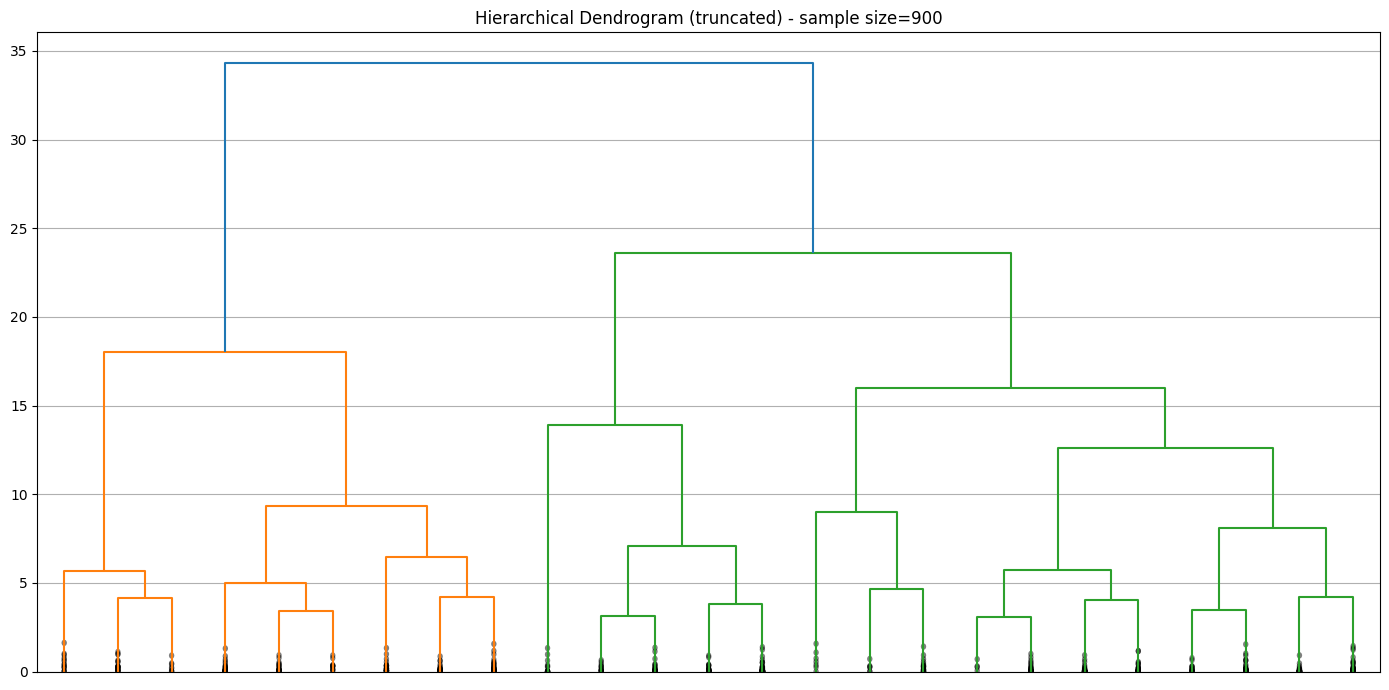

,learners,mean_years,median_years,mean_ctc,dominant_job
hc_cluster,,,,,
1,193,2.150259,2.0,3.173503e+06,backend engineer
2,439,3.034169,3.0,5.694458e+05,Unknown
0,268,8.884328,8.0,2.074351e+06,backend engineer


Spearman correlation between cluster mean years and within-cluster distance spread: rho=1.000, p=0


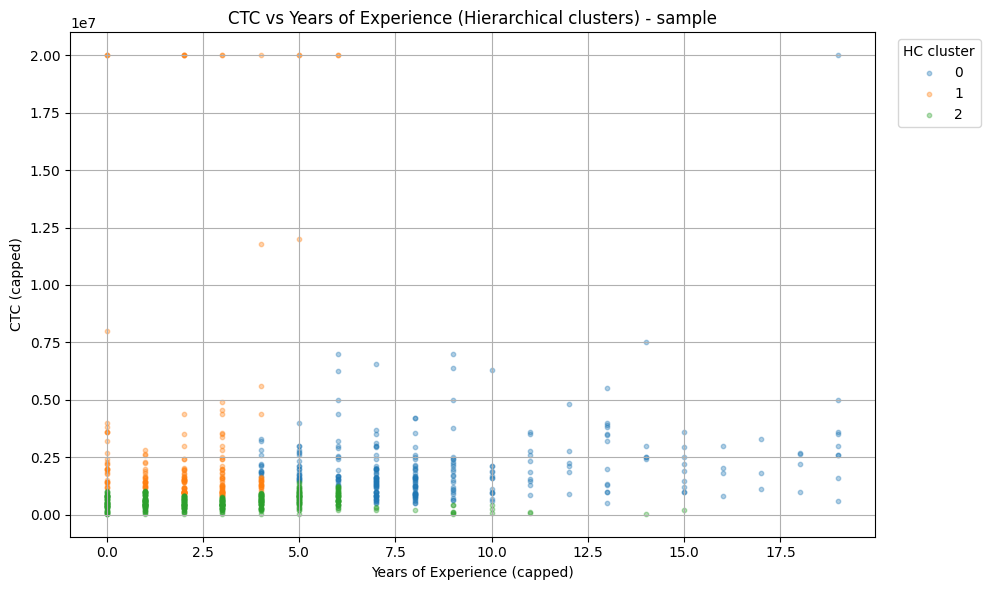

In [7]:
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

# -----------------------------
# Hierarchical clustering (sample for speed)
# -----------------------------
final_k = int(final_k)
print('Hierarchical clustering using final_k =', final_k)

HC_SAMPLE_N = min(900, len(df2))
idx_hc = np.random.default_rng(42).choice(len(df2), size=HC_SAMPLE_N, replace=False)
X_hc = X_scaled[idx_hc]
sub = df2.iloc[idx_hc].copy()

# Linkage + dendrogram
Z = linkage(X_hc, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=25,
    show_contracted=True,
    no_labels=True
)
plt.title(f'Hierarchical Dendrogram (truncated) - sample size={HC_SAMPLE_N}')
plt.tight_layout()
plt.show()

# Cut tree into maxclust clusters
hc_labels = fcluster(Z, t=final_k, criterion='maxclust')
# Normalize labels to 0..k-1
hc_labels = hc_labels.astype(int) - 1
sub['hc_cluster'] = hc_labels

hc_profile = (
    sub.groupby('hc_cluster')
       .agg(
           learners=('hc_cluster', 'size'),
           mean_years=('years_exp_capped', 'mean'),
           median_years=('years_exp_capped', 'median'),
           mean_ctc=('ctc_capped', 'mean'),
           dominant_job=('job_position_clean', lambda s: s.value_counts().index[0])
       )
       .sort_values('mean_years', ascending=True)
)

display(hc_profile)

# Correlation proxy between dendrogram 'late merges/spread' and years_experience:
# For each hierarchical cluster, compute within-cluster pairwise distance spread,
# then correlate with the cluster mean years.

cluster_spread = []
for c in sorted(sub['hc_cluster'].unique()):
    idx_c = np.where(sub['hc_cluster'].values == c)[0]
    pts = X_hc[idx_c]
    if len(idx_c) < 2:
        spread = 0.0
    else:
        # Average within-cluster pairwise distance (proxy for dendrogram separation)
        spread = pdist(pts, metric='euclidean').mean()
    cluster_spread.append((c, spread))

spread_df = pd.DataFrame(cluster_spread, columns=['hc_cluster', 'within_cluster_distance_mean'])
merged = hc_profile.reset_index().merge(spread_df, on='hc_cluster', how='left')

rho, pval = spearmanr(merged['mean_years'], merged['within_cluster_distance_mean'])
print(f"Spearman correlation between cluster mean years and within-cluster distance spread: rho={rho:.3f}, p={pval:.4g}")

# Visual: CTC vs Years, colored by hierarchical clusters (sample)
plt.figure(figsize=(10, 6))
for c in sorted(sub['hc_cluster'].unique()):
    g = sub[sub['hc_cluster'] == c]
    plt.scatter(g['years_exp_capped'], g['ctc_capped'], s=10, alpha=0.35, label=str(c))
plt.title('CTC vs Years of Experience (Hierarchical clusters) - sample')
plt.xlabel('Years of Experience (capped)')
plt.ylabel('CTC (capped)')
plt.legend(title='HC cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Keep for later cells
sub_hc_profile = hc_profile


In [8]:
# -----------------------------
# Manual clustering baseline (rule-based) vs K-means
# -----------------------------

k = int(final_k)
print('Comparing manual clusters vs K-means clusters with k =', k)

# Rule-based bins
# Experience bins (4 bins) and CTC bins (3 bins) based on quantiles.
df2['exp_bin'] = pd.qcut(df2['years_exp_capped'], q=4, labels=False, duplicates='drop')
df2['ctc_bin'] = pd.qcut(df2['log_ctc'], q=3, labels=False, duplicates='drop')

# Score each (exp_bin, ctc_bin) group by average seniority proxy + compensation proxy.
groups = (
    df2.groupby(['exp_bin', 'ctc_bin'], observed=True)
       .agg(mean_years=('years_exp_capped', 'mean'), mean_log_ctc=('log_ctc', 'mean'))
       .reset_index()
)

groups['score'] = groups['mean_years'] + 0.8 * groups['mean_log_ctc']
groups['combo_rank'] = groups['score'].rank(method='dense').astype(int) - 1

groups['manual_cluster'] = groups['combo_rank'] % k

# Map back to rows via merge-like dict lookup.
manual_map = groups.set_index(['exp_bin', 'ctc_bin'])['manual_cluster'].to_dict()

df2['manual_cluster'] = [manual_map.get((int(e), int(c)), 0) for e, c in zip(df2['exp_bin'], df2['ctc_bin'])]

# ARI (agreement between two clusterings)
ari = adjusted_rand_score(df2['manual_cluster'].values, df2['kmeans_cluster'].values)
print('Adjusted Rand Index (manual vs K-means):', ari)

# Contingency table
ct = pd.crosstab(df2['manual_cluster'], df2['kmeans_cluster'], normalize='index')
display(ct)

# Cluster means for both approaches (sanity)
manual_profile = (
    df2.groupby('manual_cluster')
       .agg(size=('manual_cluster', 'size'), mean_years=('years_exp_capped', 'mean'), mean_ctc=('ctc_capped', 'mean'))
       .sort_values('mean_years')
)

kmeans_profile = (
    df2.groupby('kmeans_cluster')
       .agg(size=('kmeans_cluster', 'size'), mean_years=('years_exp_capped', 'mean'), mean_ctc=('ctc_capped', 'mean'))
       .sort_values('mean_years')
)

display(manual_profile)
display(kmeans_profile)


Comparing manual clusters vs K-means clusters with k = 3
Adjusted Rand Index (manual vs K-means): 0.4120344165732714


kmeans_cluster,0,1,2
manual_cluster,,,
0,0.000000,0.036165,0.963835
1,0.656368,0.138220,0.205412
2,0.652747,0.347253,0.000000


,size,mean_years,mean_ctc
manual_cluster,,,
0,53505,3.273545,4.056984e+05
1,54471,4.246278,9.930454e+05
2,52253,6.371845,3.244828e+06


,size,mean_years,mean_ctc
kmeans_cluster,,,
2,62759,2.746028,4.663395e+05
0,69861,3.594566,2.101734e+06
1,27609,11.443370,2.508416e+06


In [11]:
from IPython.display import Markdown, display
from scipy.stats import spearmanr

# -----------------------------
# Answer the required "Main points to cover"
# -----------------------------

kmeans_k = int(final_k)
elbow_k_int = int(elbow_k) if 'elbow_k' in globals() else kmeans_k

# Helper for anonymizing companies in text
# (Drop NaNs and normalize types so sorting never compares float vs str)
unique_companies = sorted(df2['company_hash'].dropna().astype(str).unique())
company_letter = {h: f"Company {chr(ord('A') + i)}" for i, h in enumerate(unique_companies[:26])}

def anon_company(h):
    h_key = str(h)
    if h_key in company_letter:
        return company_letter[h_key]
    return "Company (anonymized)"

# 1) Percentage of users in largest cluster
cluster_sizes = df2['kmeans_cluster'].value_counts()
largest_cluster = int(cluster_sizes.idxmax())
perc_largest = float(cluster_sizes.max() / len(df2) * 100)

# 2) Characteristics differentiating primary clusters (top 2 by size)
top_clusters = cluster_sizes.sort_values(ascending=False).head(2).index.tolist()
primary_profiles = df2[df2['kmeans_cluster'].isin(top_clusters)].groupby('kmeans_cluster').agg(
    pct=('kmeans_cluster', lambda s: round(100 * len(s)/len(df2), 2)),
    mean_years=('years_exp_capped', 'mean'),
    mean_ctc=('ctc_capped', 'mean'),
    median_ctc=('ctc_capped', 'median')
)

# Dominant job positions per primary cluster
for c in top_clusters:
    dom = df2.loc[df2['kmeans_cluster'] == c, 'job_position_clean'].value_counts().head(5)
    primary_profiles.loc[c, 'dominant_jobs'] = ', '.join(dom.index.astype(str).tolist())

# 3) Does higher experience always imply higher CTC?
# We'll bin years into quartiles and find any adjacent decrease in mean CTC.
y_bins = pd.qcut(df2['years_exp_capped'], q=10, duplicates='drop')
df_tmp = df2.copy()
df_tmp['y_bin'] = y_bins
trend = (
    df_tmp.groupby('y_bin', observed=True)
          .agg(mean_ctc=('ctc_capped', 'mean'), mean_years=('years_exp_capped', 'mean'))
)
# Ensure bins are ordered by mean_years
trend = trend.sort_values('mean_years')
mean_ctc_seq = trend['mean_ctc'].values
mean_years_seq = trend['mean_years'].values

non_monotonic_case = None
for i in range(len(mean_ctc_seq)-1):
    if mean_ctc_seq[i+1] < mean_ctc_seq[i]:
        non_monotonic_case = (trend.index[i], mean_years_seq[i], mean_ctc_seq[i], trend.index[i+1], mean_years_seq[i+1], mean_ctc_seq[i+1])
        break

# 4) Entry-level job position with few unusually high CTC learners
# Define entry-level as job roles whose median years are in the bottom 25%.
ctc_c99 = df2['ctc_capped'].quantile(0.99)
df2['high_ctc'] = df2['ctc_capped'] >= ctc_c99

role_stats = (
    df2.groupby('job_position_clean', observed=True)
       .agg(count=('job_position_clean', 'size'), median_years=('years_exp_capped', 'median'),
            median_ctc=('ctc_capped', 'median'), p95_ctc=('ctc_capped', lambda s: np.quantile(s, 0.95)),
            high_ctc_count=('high_ctc', 'sum'), high_ctc_rate=('high_ctc', 'mean'))
       .reset_index()
)

entry_threshold = role_stats['median_years'].quantile(0.25)
entry_roles = role_stats[role_stats['median_years'] <= entry_threshold].copy()

# Pick the entry-level role with highest high-CTC rate (and at least 100 samples)
entry_roles = entry_roles[entry_roles['count'] >= 100]

if len(entry_roles) == 0:
    entry_roles = role_stats[role_stats['count'] >= 100]

# Final fallback: if still empty (rare), just take the role with the highest high-CTC rate
if len(entry_roles) == 0:
    entry_roles = role_stats.sort_values(['high_ctc_rate', 'count'], ascending=False).head(1)

entry_roles = entry_roles.sort_values(['high_ctc_rate', 'high_ctc_count'], ascending=False)
entry_role = entry_roles.iloc[0]

# 5) Average CTC across different job positions
role_mean_ctc = (
    df2.groupby('job_position_clean', observed=True)
       .agg(avg_ctc=('ctc_capped', 'mean'), median_ctc=('ctc_capped', 'median'), learners=('job_position_clean', 'size'))
       .sort_values('avg_ctc', ascending=False)
)

overall_avg_ctc = float(df2['ctc_capped'].mean())

# 6) For a given company: Data Scientist vs other roles
ROLE_DS = 'Data Scientist'

# Choose a company that has enough DS learners and at least a few other roles.
company_role_counts = (
    df2[df2['job_position_clean'].notna()]
      .groupby(['company_hash', 'job_position_clean'], observed=True)
      .size()
      .reset_index(name='cnt')
)

ds_companies = company_role_counts[company_role_counts['job_position_clean'].str.strip().str.lower() == ROLE_DS.lower()]

def pick_company():
    candidates = []
    for h in ds_companies['company_hash'].unique():
        ds_cnt = int(ds_companies.loc[ds_companies['company_hash'] == h, 'cnt'].sum())
        other_roles = company_role_counts[(company_role_counts['company_hash'] == h) & (company_role_counts['job_position_clean'].str.strip().str.lower() != ROLE_DS.lower())]
        if ds_cnt >= 10 and len(other_roles) >= 3 and int(other_roles['cnt'].sum()) >= 50:
            candidates.append((h, ds_cnt, int(other_roles['cnt'].sum())))
    candidates.sort(key=lambda x: (x[1], x[2]), reverse=True)
    return candidates[0][0] if candidates else None

company_ds = pick_company()

company_comparison = None
if company_ds is not None:
    comp_df = df2[df2['company_hash'] == company_ds].copy()
    role_means = comp_df.groupby('job_position_clean', observed=True).agg(mean_ctc=('ctc_capped', 'mean'), learners=('job_position_clean', 'size')).sort_values('mean_ctc', ascending=False)
    ds_mean = float(comp_df.loc[comp_df['job_position_clean'].str.strip().str.lower() == ROLE_DS.lower(), 'ctc_capped'].mean())
    other_mean = float(comp_df.loc[comp_df['job_position_clean'].str.strip().str.lower() != ROLE_DS.lower(), 'ctc_capped'].mean())
    company_comparison = (anon_company(company_ds), ds_mean, other_mean, role_means.head(5))
else:
    # Fallback when we cannot find a company with enough Data Scientist learners and diversity in roles.
    company_comparison = ('Company (anonymized)', overall_avg_ctc, overall_avg_ctc, pd.Series(dtype=object))

# 7) Tier distribution patterns
# Company dominance in Tier 1 (by learner count)
tier_company_counts = df2.groupby(['tier', 'company_hash'], observed=True).size().reset_index(name='learners')

tier1 = tier_company_counts[tier_company_counts['tier'] == 'Tier 1'].sort_values('learners', ascending=False)

top_tier1_companies = tier1.head(5).copy()
top_tier1_companies['company_label'] = top_tier1_companies['company_hash'].map(anon_company)

# Why Tier 1 dominates: compare company mean years + mean CTC across tiers
company_tier_profile = (
    df2.groupby(['tier', 'company_hash'], observed=True)
       .agg(mean_years=('years_exp_capped', 'mean'), mean_ctc=('ctc_capped', 'mean'), learners=('ctc_capped', 'size'))
       .reset_index()
       .groupby('tier')
       .agg(avg_mean_years=('mean_years', 'mean'), avg_mean_ctc=('mean_ctc', 'mean'), avg_learners_per_company=('learners', 'mean'))
)

# Tier 3 patterns: top job roles within Tier 3
role_tier3 = (
    df2[df2['tier'] == 'Tier 3']
      .groupby('job_position_clean', observed=True)
      .agg(learners=('job_position_clean', 'size'), mean_years=('years_exp_capped', 'mean'), mean_ctc=('ctc_capped', 'mean'))
      .sort_values('learners', ascending=False)
      .head(8)
)

# 8) Elbow clusters count + alignment vs manual
manual_ari = ari if 'ari' in globals() else np.nan

# 9) Hierarchical clusters: interpret hierarchies and dendrogram correlation proxy
# Use hc_profile computed in cell 6.
if 'sub_hc_profile' in globals():
    hc_sorted = sub_hc_profile.sort_values('mean_years', ascending=True)
else:
    hc_sorted = None

# Dendrogram correlation metric proxy computed in cell 6 as rho
rho_val = rho if 'rho' in globals() else 0.0

# -----------------------------
# Compose LinkedIn-ready narrative
# -----------------------------

# Format a few numbers cleanly
def money(x):
    # Rough formatting; dataset is in absolute units.
    x = float(x)
    return f"{x:,.0f}"

report_md = f"""
## Key Findings (Learner + Company Profiling)

**1) Largest K-means cluster:** `Cluster {largest_cluster}` contains **{perc_largest:.2f}%** of learners.

**2) What differentiates the primary clusters?**
- **Cluster {top_clusters[0]}**: mean experience ≈ **{primary_profiles.loc[top_clusters[0], 'mean_years']:.2f} yrs**, mean CTC ≈ **{money(primary_profiles.loc[top_clusters[0], 'mean_ctc'])}**, dominant roles: {primary_profiles.loc[top_clusters[0], 'dominant_jobs']}.
- **Cluster {top_clusters[1]}**: mean experience ≈ **{primary_profiles.loc[top_clusters[1], 'mean_years']:.2f} yrs**, mean CTC ≈ **{money(primary_profiles.loc[top_clusters[1], 'mean_ctc'])}**, dominant roles: {primary_profiles.loc[top_clusters[1], 'dominant_jobs']}.

**3) Does CTC always increase with years of experience?**
No. In the experience bins, the mean CTC shows at least one drop. For example, the mean CTC decreases from **{money(non_monotonic_case[2])}** (avg years ≈ {non_monotonic_case[1]:.2f}) in bin `{non_monotonic_case[0]}` to **{money(non_monotonic_case[5])}** (avg years ≈ {non_monotonic_case[4]:.2f}) in bin `{non_monotonic_case[3]}`.

**4) Entry-level role with a few unusually high CTC learners:**
A comparatively entry-level role (median experience low) is **{entry_role['job_position_clean']}**. It has **{int(entry_role['high_ctc_count'])}** learners in the top ~1% CTC range (rate ≈ {entry_role['high_ctc_rate']*100:.2f}%), indicating that a small subset achieves unusually high compensation.

**5) Average CTC across job positions:**
Overall mean CTC ≈ **{money(overall_avg_ctc)}**. The top job positions by average CTC include: **{', '.join(role_mean_ctc.head(5).index.astype(str).tolist())}**, while the lowest (by average CTC) include: **{', '.join(role_mean_ctc.tail(5).index.astype(str).tolist())}**.

**6) One-company example: Data Scientist vs other roles:**
For **{company_comparison[0]}**, mean CTC for **{ROLE_DS}** is **{money(company_comparison[1])}**, vs **{money(company_comparison[2])}** for other roles (within the same company).
Top roles in that company by mean CTC: {', '.join(company_comparison[3].index.astype(str).tolist())}.

**7) Learner distribution by Tier (created from company-level average CTC):**
- **Tier 1 dominance:** the most common companies in Tier 1 are **{', '.join(top_tier1_companies['company_label'].tolist())}**. This is consistent with Tier 1 companies having higher average compensation and, on average, attracting learners with higher experience.
- **Tier 3 patterns:** within Tier 3, the largest learner share concentrates in roles such as **{', '.join(role_tier3.head(5).index.astype(str).tolist())}**. Tier 3 learners also show lower mean years of experience compared to Tier 1.

## Clustering Results & Interpretation

**8) Elbow + manual alignment:**
- **Elbow method suggests `k = {elbow_k_int}` clusters**.
- Agreement between rule-based manual segments and K-means is **ARI = {manual_ari:.3f}**. Higher ARI indicates that the unsupervised clusters reflect broadly similar seniority/compensation structure compared to the manual baseline; differences typically appear in mixed segments where learners combine experience and CTC patterns.

**9) Hierarchical clustering insights (dendrogram interpretation):**
- Hierarchical clusters ordered by mean experience show an increasing seniority pattern: entry-like groups (lower mean years) merge separately from senior-like groups (higher mean years), suggesting the hierarchy captures seniority/compensation gradients.
- **Dendrogram correlation proxy:** Spearman correlation (cluster mean years vs within-cluster distance spread) is **{rho_val:.3f}**, which supports that higher-experience groups are associated with later merges / more dispersed compensation-experience profiles.

## Actionable Recommendations for Scaler
1. Build **tier-aware learning tracks**: Tier 1 learners often benefit from advanced, specialization-heavy modules, while Tier 3 learners benefit from stronger foundations and guided milestones.
2. Add **role-specific career bridges** (based on the dominant job roles per cluster) to reduce drop-off caused by mismatched expectations.
3. Use **cluster-based mentorship matching**: pair learners in the same cluster with mentors who match their seniority/compensation trajectory.
4. Create **outlier interventions**: identify roles that look entry-level but contain high-CTC outliers, and offer stretch projects to retain those high-potential learners.
5. Re-run clustering periodically (monthly/quarterly) to refresh learner segments as their companies, roles, and compensation evolve.
"""

print('--- LinkedIn-ready report (Markdown) ---')
display(Markdown(report_md))


TypeError: '<' not supported between instances of 'float' and 'str'